In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [66]:
!pwd

/Users/isaac/code/ishane0620/jobable/notebooks


In [67]:
df = pd.read_csv('../data/job_title_des.csv')

In [68]:
df.head()

,Unnamed: 0,Job Title,Job Description
0,0,Flutter Developer,We are looking for hire experts flutter develo...
1,1,Django Developer,PYTHON/DJANGO (Developer/Lead) - Job Code(PDJ ...
2,2,Machine Learning,"Data Scientist (Contractor)\n\nBangalore, IN\n..."
3,3,iOS Developer,JOB DESCRIPTION:\n\nStrong framework outside o...
4,4,Full Stack Developer,job responsibility full stack engineer – react...


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2277 entries, 0 to 2276
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       2277 non-null   int64 
 1   Job Title        2277 non-null   object
 2   Job Description  2277 non-null   object
dtypes: int64(1), object(2)
memory usage: 53.5+ KB


In [70]:
df.describe()

,Unnamed: 0
count,2277.000000
mean,1187.974089
std,694.438444
min,0.000000
25%,585.000000
50%,1183.000000
75%,1782.000000
max,2403.000000


In [71]:
desc1 = df['Job Description'][0]

In [72]:
# desc1.split()
# df['bag of words'] = df['Job Description'].map(lambda x: x.lower().split())
df["bag of words"] = df["Job Description"].map(
    lambda x: [t for t in re.split(r"[ \n.,!?;:()\[\]{}\"'’\-_/]+", x.lower()) if t]
)

df['bag of words']

0       [we, are, looking, for, hire, experts, flutter...
1       [python, django, developer, lead, job, code, p...
2       [data, scientist, contractor, bangalore, in, r...
3       [job, description, strong, framework, outside,...
4       [job, responsibility, full, stack, engineer, –...
                              ...                        
2272    [job, summary, published, on, 26, days, ago, v...
2273    [business, entity, cisco, umbrella, focus, clo...
2274    [urgently, reqd, in, a, college, in, mohali, n...
2275    [key, responsibilities, team, leads, for, smal...
2276    [leslie, hindman, auctioneer, one, nation, s, ...
Name: bag of words, Length: 2277, dtype: object

In [73]:
def get_wordcounts(ser):
    word_counts = {}
    document = []
    ser.map(lambda x: document.append(x))
    for sentence in document:
        for word in sentence:
            word_counts[word] = word_counts.get(word, 0) + 1
    return word_counts

In [74]:
counts = (get_wordcounts(df['bag of words']))
word_counts = dict(sorted(counts.items(), key=lambda x: -x[1]))
word_counts

{'and': 28187,
 'to': 13428,
 'of': 12527,
 'the': 11235,
 'in': 10205,
 'experience': 9620,
 'with': 8385,
 'a': 7395,
 'for': 5610,
 'work': 4792,
 'development': 4148,
 'on': 4051,
 'or': 3678,
 'you': 3414,
 'we': 3245,
 'knowledge': 3222,
 'as': 3180,
 'is': 3180,
 'team': 3096,
 'software': 2973,
 'design': 2876,
 'data': 2751,
 'years': 2680,
 'our': 2663,
 'be': 2631,
 'job': 2582,
 'skills': 2576,
 'are': 2563,
 'preferred': 2471,
 's': 2225,
 'will': 2147,
 'required': 2134,
 'have': 2129,
 'understanding': 2089,
 'working': 1993,
 'web': 1960,
 'year': 1948,
 'time': 1943,
 'application': 1938,
 'that': 1892,
 'strong': 1851,
 'an': 1771,
 'code': 1769,
 'full': 1679,
 'new': 1670,
 '&': 1665,
 '·': 1627,
 '1': 1604,
 'applications': 1601,
 'end': 1561,
 'business': 1558,
 'ability': 1548,
 'good': 1543,
 'developer': 1535,
 '00': 1466,
 'javascript': 1452,
 'at': 1451,
 'technical': 1437,
 '•': 1428,
 'your': 1421,
 'database': 1419,
 'technology': 1416,
 'system': 1408,
 '

In [75]:
df_word_counts = pd.DataFrame(list(word_counts.items()))
df_word_counts

,0,1
0,and,28187
1,to,13428
2,of,12527
3,the,11235
4,in,10205
...,...,...
17825,205,1
17826,theecsinc,1
17827,leslie,1
17828,hindman,1


<BarContainer object of 1000 artists>

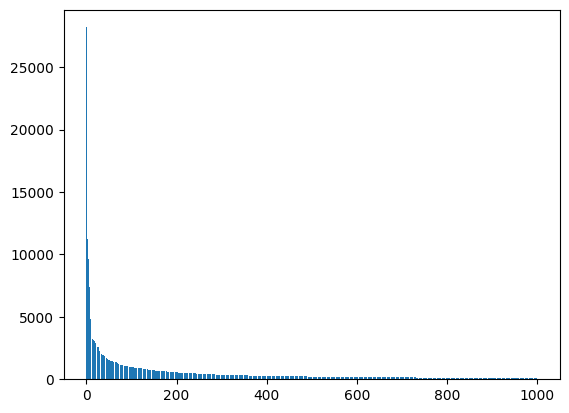

In [76]:
df_word_counts_1000 = df_word_counts.iloc[:1000]
plt.bar(df_word_counts_1000.index, df_word_counts_1000[1])


In [77]:
stop_words = set(stopwords.words("english"))

def tokenize_and_clean(text):
    tokens = word_tokenize(text.lower())
    return [t for t in tokens if t.isalpha() and t not in stop_words]


In [78]:
df_word_counts_1000[:50]
all_words = list(df_word_counts[0])
important_words = tokenize_and_clean(' '.join(all_words))

In [79]:
data_keywords = [
    # Core Roles & Job Titles
    "data scientist", "senior data scientist", "machine learning engineer", "applied scientist",
    "research scientist", "data analyst", "business analyst", "bi analyst", "analytics engineer",
    "data engineer", "etl developer", "big data engineer", "mlops engineer", "ml engineer",
    "ai engineer", "decision scientist", "quantitative analyst", "quant analyst", "statistician",
    "data science intern", "data engineer intern", "analytics intern",

    # Programming Languages
    "python", "r", "sql", "scala", "java", "julia", "c", "c++", "c#", "matlab", "javascript",
    "typescript", "sas", "stata",

    # Python Data & ML Ecosystem
    "numpy", "pandas", "scipy", "scikit-learn", "sklearn", "statsmodels", "tensorflow", "keras",
    "pytorch", "jax", "xgboost", "lightgbm", "catboost", "prophet", "fbprophet", "pymc", "pymc3",
    "pymc4", "pyspark", "sparklyr", "dask", "ray", "rapids", "cudf", "cuml",

    # R Ecosystem
    "tidyverse", "dplyr", "tidyr", "ggplot2", "data.table", "caret", "mlr", "shiny", "rmarkdown",

    # Data Visualization & BI Tools
    "matplotlib", "seaborn", "plotly", "bokeh", "altair", "ggplot", "tableau", "tableau server",
    "tableau prep", "power bi", "looker", "looker studio", "mode analytics", "qlik", "qlikview",
    "qlik sense", "superset", "metabase", "redash", "grafana", "kibana", "excel dashboards",
    "google data studio",

    # Databases & Query Engines
    "mysql", "postgresql", "postgres", "sql server", "oracle", "sqlite", "snowflake", "bigquery",
    "amazon redshift", "redshift", "azure synapse", "teradata", "vertica", "mariadb", "db2",
    "presto", "trino", "hive", "impala", "clickhouse", "elasticsearch", "mongodb", "cassandra",
    "redis", "dynamodb", "neo4j",

    # Big Data & Distributed Computing
    "hadoop", "hdfs", "mapreduce", "spark", "apache spark", "spark sql", "spark streaming",
    "kafka", "apache kafka", "flink", "apache flink", "storm", "kinesis", "beam", "apache beam",
    "airflow on spark", "emr", "databricks", "cloudera", "hortonworks",

    # Cloud Platforms & Managed Data Services
    "amazon web services", "aws", "google cloud platform", "gcp", "microsoft azure", "azure",
    "cloud computing", "serverless", "aws s3", "s3", "aws lambda", "aws glue", "aws athena",
    "aws emr", "aws sagemaker", "azure data lake", "azure databricks", "azure synapse", "azure ml",
    "azure functions", "google bigquery", "google cloud storage", "gcs", "google cloud functions",
    "vertex ai", "google cloud composer", "gcp dataflow", "gcp dataproc",
    "snowflake on aws", "snowflake on azure", "snowflake on gcp",

    # Data Engineering, ETL, and Workflow Orchestration
    "etl", "elt", "data pipelines", "batch processing", "streaming pipelines", "real-time data",
    "cdc", "change data capture", "data warehouse", "data lake", "data lakehouse", "data modeling",
    "dimensional modeling", "star schema", "snowflake schema", "kimball", "inmon", "olap", "oltp",
    "data integration", "data ingestion", "data transformation", "data normalization",
    "denormalization", "data quality", "data governance", "data lineage",
    "master data management", "mdm", "apache airflow", "airflow", "luigi", "prefect", "dagster",
    "dbt", "dbt core", "dbt cloud", "fivetran", "stitch", "talend", "informatica", "ssis",
    "data factory",

    # Machine Learning Fundamentals & Techniques
    "supervised learning", "unsupervised learning", "reinforcement learning", "semi-supervised learning",
    "self-supervised learning", "classification", "regression", "clustering", "anomaly detection",
    "outlier detection", "recommendation systems", "recommender systems", "ranking",
    "time series forecasting", "forecasting", "dimensionality reduction", "feature selection",
    "feature extraction", "cross-validation", "hyperparameter tuning", "model selection",
    "ensemble methods", "bagging", "boosting", "stacking", "random forests", "gradient boosting",
    "k-nearest neighbors", "knn", "support vector machines", "svm", "logistic regression",
    "linear regression", "ridge regression", "lasso", "elastic net", "decision trees",
    "naive bayes", "k-means", "hierarchical clustering", "dbscan", "pca", "t-sne", "umap",
    "arima", "sarima", "var", "prophet", "survival analysis",

    # Deep Learning & Specialized ML
    "neural networks", "deep learning", "cnn", "convolutional neural networks", "rnn",
    "recurrent neural networks", "lstm", "gru", "transformers", "attention mechanisms", "gan",
    "generative adversarial networks", "autoencoders", "variational autoencoders", "vae",
    "sequence models", "sequence-to-sequence", "seq2seq", "encoder-decoder", "computer vision",
    "image classification", "object detection", "segmentation", "opencv", "yolo", "mask r-cnn",
    "nlp", "natural language processing", "text classification", "named entity recognition", "ner",
    "sentiment analysis", "topic modeling", "lda", "word embeddings", "word2vec", "glove",
    "bert", "gpt", "large language models", "llms", "speech recognition",
    "recommendation engines", "collaborative filtering", "content-based filtering", "bandits",
    "contextual bandits", "reinforcement learning",

    # Statistics, Mathematics & Experimentation
    "descriptive statistics", "inferential statistics", "probability", "probability distributions",
    "hypothesis testing", "a/b testing", "experimentation", "statistical modeling",
    "regression analysis", "anova", "nonparametric tests", "confidence intervals", "p-values",
    "bayesian statistics", "bayesian inference", "mcmc", "markov chain monte carlo",
    "monte carlo simulation", "maximum likelihood estimation", "mle", "sampling methods",
    "bootstrapping", "time series analysis", "stochastic processes", "linear algebra",
    "optimization", "convex optimization",

    # MLOps, Model Serving & Productionization
    "mlops", "model deployment", "model serving", "production machine learning", "model monitoring",
    "model lifecycle", "ml pipelines", "ml orchestration", "ml platforms", "ci/cd",
    "continuous integration", "continuous delivery", "docker", "containers", "kubernetes", "k8s",
    "kubeflow", "mlflow", "experiment tracking", "model registry", "feature store", "feast",
    "tecton", "pipeline automation", "batch scoring", "online scoring", "shadow deployment",
    "canary deployment", "model drift", "data drift", "model explainability",
    "explainable ai", "xai", "shap", "lime", "fairness", "responsible ai",

    # General Software Engineering & DevOps Skills
    "git", "github", "gitlab", "bitbucket", "version control", "branching", "pull requests",
    "code review", "unit testing", "integration testing", "pytest", "unittest",
    "test-driven development", "tdd", "software engineering", "clean code", "design patterns",
    "rest apis", "building apis", "flask", "django", "fastapi", "microservices",
    "command line", "linux", "unix", "bash", "shell scripting", "jenkins",
    "github actions", "circleci", "azure devops", "terraform", "infrastructure as code",
    "monitoring", "logging", "prometheus", "elk stack",

    # Data Cleaning, Wrangling & Feature Engineering
    "data cleaning", "data wrangling", "data preprocessing", "data munging",
    "missing data imputation", "outlier handling", "feature engineering", "feature scaling",
    "normalization", "standardization", "encoding categorical variables", "one-hot encoding",
    "label encoding", "target encoding", "feature importance", "text preprocessing",
    "tokenization", "stemming", "lemmatization", "stop word removal", "n-grams",
    "regular expressions", "regex",

    # Analytics, Business, and Domain Keywords
    "business intelligence", "descriptive analytics", "diagnostic analytics", "predictive analytics",
    "prescriptive analytics", "kpi", "kpis", "metrics", "dashboards", "reporting",
    "performance metrics", "customer analytics", "marketing analytics", "product analytics",
    "growth analytics", "financial analytics", "operations analytics", "risk analytics",
    "churn analysis", "customer segmentation", "cohort analysis", "funnel analysis",
    "pricing analytics", "supply chain analytics", "logistics optimization", "fraud detection",
    "credit risk", "marketing attribution", "experimentation platform", "stakeholder management",
    "data storytelling", "data-driven decision making",

    # Common Tools for Analysts
    "excel", "microsoft excel", "google sheets", "pivot tables", "vlookup", "index match",
    "excel macros", "vba", "jupyter", "jupyter notebook", "jupyterlab", "rstudio", "vs code",
    "spyder", "sql queries", "ad-hoc analysis", "exploratory data analysis", "eda",
    "reporting automation",

    # Soft Skills & Impact Phrases
    "communication skills", "strong communication", "presenting insights", "stakeholder communication",
    "cross-functional collaboration", "working with product managers", "working with engineers",
    "working with business stakeholders", "problem solving", "critical thinking",
    "analytical mindset", "attention to detail", "self-starter", "fast learner", "leadership",
    "mentoring", "leading projects", "project management", "agile", "scrum", "kanban",

    # Education & Certifications Keywords
    "bachelor's degree in computer science", "bachelor's in statistics",
    "bachelor's in mathematics", "bachelor's in engineering",
    "master's degree in data science", "master's in computer science",
    "master's in statistics", "phd", "coursera", "edx", "udacity", "datacamp", "kaggle",
    "aws certified machine learning", "aws certified data analytics",
    "google professional data engineer",
    "google professional machine learning engineer",
    "microsoft certified data scientist",
    "databricks certification"
]
data_keywords = list(set(data_keywords))

len(data_keywords)

523

In [80]:
df['key words'] = df['bag of words'].map(lambda x : [i for i in x if i in data_keywords])

In [81]:
df.head()

,Unnamed: 0,Job Title,Job Description,bag of words,key words
0,0,Flutter Developer,We are looking for hire experts flutter develo...,"[we, are, looking, for, hire, experts, flutter...",[]
1,1,Django Developer,PYTHON/DJANGO (Developer/Lead) - Job Code(PDJ ...,"[python, django, developer, lead, job, code, p...","[python, django, python, django, flask, linux,..."
2,2,Machine Learning,"Data Scientist (Contractor)\n\nBangalore, IN\n...","[data, scientist, contractor, bangalore, in, r...","[reporting, python, python, java, spark, pytor..."
3,3,iOS Developer,JOB DESCRIPTION:\n\nStrong framework outside o...,"[job, description, strong, framework, outside,...",[c]
4,4,Full Stack Developer,job responsibility full stack engineer – react...,"[job, responsibility, full, stack, engineer, –...","[agile, javascript]"


In [82]:
df_resume = pd.read_csv('../data/Resume.csv')
df_resume

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR
...,...,...,...,...
2479,99416532,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2480,24589765,"GOVERNMENT RELATIONS, COMMUNICATIONS ...","<div class=""fontsize fontface vmargins hmargin...",AVIATION
2481,31605080,GEEK SQUAD AGENT Professional...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2482,21190805,PROGRAM DIRECTOR / OFFICE MANAGER ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION


In [83]:
df_resume['Category'].unique()

array(['HR', 'DESIGNER', 'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE',
       'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE',
       'BPO', 'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'AUTOMOBILE',
       'CHEF', 'FINANCE', 'APPAREL', 'ENGINEERING', 'ACCOUNTANT',
       'CONSTRUCTION', 'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION'],
      dtype=object)

In [84]:
df_resume = df_resume[['ID', 'Resume_str', 'Category']]
df_resume

,ID,Resume_str,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,33176873,HR DIRECTOR Summary Over 2...,HR
3,27018550,HR SPECIALIST Summary Dedica...,HR
4,17812897,HR MANAGER Skill Highlights ...,HR
...,...,...,...
2479,99416532,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,AVIATION
2480,24589765,"GOVERNMENT RELATIONS, COMMUNICATIONS ...",AVIATION
2481,31605080,GEEK SQUAD AGENT Professional...,AVIATION
2482,21190805,PROGRAM DIRECTOR / OFFICE MANAGER ...,AVIATION


In [85]:
df_resume['bag of words'] = df_resume["Resume_str"].map(
    lambda x: [t for t in re.split(r"[ \n.,!?;:()\[\]{}\"'’\-_/]+", x.lower()) if t]
)
df_resume.head()

,ID,Resume_str,Category,bag of words
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,"[hr, administrator, marketing, associate, hr, ..."
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...",HR,"[hr, specialist, us, hr, operations, summary, ..."
2,33176873,HR DIRECTOR Summary Over 2...,HR,"[hr, director, summary, over, 20, years, exper..."
3,27018550,HR SPECIALIST Summary Dedica...,HR,"[hr, specialist, summary, dedicated, driven, a..."
4,17812897,HR MANAGER Skill Highlights ...,HR,"[hr, manager, skill, highlights, hr, skills, h..."


In [86]:
df_resume['keywords'] = df_resume['bag of words'].map(lambda x: [i for i in x if i in data_keywords])

In [87]:
df_resume[df_resume['Category']=='ENGINEERING'].head(50)

,ID,Resume_str,Category,bag of words,keywords
1690,14206561,ENGINEERING TECHNICIAN High...,ENGINEERING,"[engineering, technician, highlights, pc, oper...","[excel, oracle, metrics, excel, oracle]"
1691,15139979,ENGINEERING ASSISTANT Summary ...,ENGINEERING,"[engineering, assistant, summary, knowledgeabl...","[leadership, reporting, monitoring, transforme..."
1692,44624796,ENGINEERING MANAGER Profile ...,ENGINEERING,"[engineering, manager, profile, dedicated, eng...","[excel, excel]"
1693,54227873,ENGINEERING INTERN Profession...,ENGINEERING,"[engineering, intern, professional, summary, a...","[c++, python, c++, python, leadership, java, l..."
1694,28005884,ENGINEERING TECHNICIAN Summar...,ENGINEERING,"[engineering, technician, summary, to, obtain,...","[storm, storm, storm, storm, storm, storm]"
1695,82246962,TEST ENGINEERING Profile I a...,ENGINEERING,"[test, engineering, profile, i, am, seeking, t...","[python, linux, sql, unix, optimization, kanba..."
1696,13149176,ENGINEERING TECHNICIAN Professi...,ENGINEERING,"[engineering, technician, professional, summar...","[regression, regression]"
1697,12022566,ENGINEERING INTERN Summary C...,ENGINEERING,"[engineering, intern, summary, candidate, with...","[anova, r, r, c++, c, anova, forecasting, fore..."
1698,20981299,ENGINEERING ASSISTANT Summary ...,ENGINEERING,"[engineering, assistant, summary, product, and...","[c, r, kanban, kpi, metrics, kpi, metrics, anova]"
1699,25919149,ENGINEERING TECHNICIAN Professi...,ENGINEERING,"[engineering, technician, professional, profil...",[]


In [ ]:
def count_score(resume_words, job_words):
    """
    job (Series), resume (Series): counts number of overlapping data keywords
    count_score(job, resume): counts repeats
    count_score(resume, job): doesn’t counts repeats
    """

    resume_words = list(resume_words)
    job_words = list(job_words)
    count = 0
    for word in job_words:
        if word in resume_words:
            count+=1
    return count


In [89]:
df

,Unnamed: 0,Job Title,Job Description,bag of words,key words
0,0,Flutter Developer,We are looking for hire experts flutter develo...,"[we, are, looking, for, hire, experts, flutter...",[]
1,1,Django Developer,PYTHON/DJANGO (Developer/Lead) - Job Code(PDJ ...,"[python, django, developer, lead, job, code, p...","[python, django, python, django, flask, linux,..."
2,2,Machine Learning,"Data Scientist (Contractor)\n\nBangalore, IN\n...","[data, scientist, contractor, bangalore, in, r...","[reporting, python, python, java, spark, pytor..."
3,3,iOS Developer,JOB DESCRIPTION:\n\nStrong framework outside o...,"[job, description, strong, framework, outside,...",[c]
4,4,Full Stack Developer,job responsibility full stack engineer – react...,"[job, responsibility, full, stack, engineer, –...","[agile, javascript]"
...,...,...,...,...,...
2272,2399,Backend Developer,Job Summary\nPublished on : 26 days ago\nVacan...,"[job, summary, published, on, 26, days, ago, v...","[postgresql, unix, mysql, sql]"
2273,2400,Full Stack Developer,business entity cisco umbrella focus cloud-bas...,"[business, entity, cisco, umbrella, focus, clo...","[agile, javascript, aws, javascript, jenkins, ..."
2274,2401,Network Administrator,Urgently reqd in a college in Mohali\nNetwork ...,"[urgently, reqd, in, a, college, in, mohali, n...",[]
2275,2402,Machine Learning,Key Responsibilities: Team leads for small or ...,"[key, responsibilities, team, leads, for, smal...",[reporting]


In [102]:
df.to_csv('../test_results/aggregate_test_results.csv')


In [94]:
df_resume[df_resume['Category']=='ENGINEERING'].iloc[5,1]

"         TEST ENGINEERING       Profile    I am seeking the challenging position with a technology company that will allow me to apply and enhance my skills of being Test Engineer to their fullest potential. Possessing over 10 years of experience in the electronics manufacturing and test engineering environment can bring high level of responsibility and technical role in your company. In addition, I am eager to contribute my creativity and hard work towards the success of your company and to the growth of the fast developing field.      Areas of Expertise          Digital/Analog and RF Circuits Design Techniques and Troubleshooting, used Agilent E5061B-3L5 LF-RF Network Analyzer for troubleshooting  Proficient with circuit board and microscope soldering skills and rework  Interpret in reading schematic diagram for AC/DC circuits  View Expert CAD Design software operating experience  TEXMAC Flying probe 9000 series program experience  Agilent 83480A Digital Communication Analyzer opera

In [93]:
df_resume

,ID,Resume_str,Category,bag of words,keywords
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,"[hr, administrator, marketing, associate, hr, ...","[leadership, reporting, leadership, reporting]"
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...",HR,"[hr, specialist, us, hr, operations, summary, ...","[metrics, reporting, reporting]"
2,33176873,HR DIRECTOR Summary Over 2...,HR,"[hr, director, summary, over, 20, years, exper...","[reporting, monitoring, leadership, excel]"
3,27018550,HR SPECIALIST Summary Dedica...,HR,"[hr, specialist, summary, dedicated, driven, a...","[excel, monitoring, excel]"
4,17812897,HR MANAGER Skill Highlights ...,HR,"[hr, manager, skill, highlights, hr, skills, h...","[excel, reporting, leadership, reporting, lead..."
...,...,...,...,...,...
2479,99416532,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,AVIATION,"[rank, sgt, e, 5, non, commissioned, officer, ...","[leadership, leadership, leadership, containers]"
2480,24589765,"GOVERNMENT RELATIONS, COMMUNICATIONS ...",AVIATION,"[government, relations, communications, and, o...","[mentoring, leadership, leadership, leadership..."
2481,31605080,GEEK SQUAD AGENT Professional...,AVIATION,"[geek, squad, agent, professional, profile, it...",[]
2482,21190805,PROGRAM DIRECTOR / OFFICE MANAGER ...,AVIATION,"[program, director, office, manager, summary, ...","[excel, excel]"


In [97]:
resume_test = df_resume[df_resume['Category']=='ENGINEERING'].iloc[5,4]
job_test = df.iloc[9,4]

In [98]:
count_score(job_test,resume_test)

6

In [103]:
df_resume

,ID,Resume_str,Category,bag of words,keywords
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,"[hr, administrator, marketing, associate, hr, ...","[leadership, reporting, leadership, reporting]"
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...",HR,"[hr, specialist, us, hr, operations, summary, ...","[metrics, reporting, reporting]"
2,33176873,HR DIRECTOR Summary Over 2...,HR,"[hr, director, summary, over, 20, years, exper...","[reporting, monitoring, leadership, excel]"
3,27018550,HR SPECIALIST Summary Dedica...,HR,"[hr, specialist, summary, dedicated, driven, a...","[excel, monitoring, excel]"
4,17812897,HR MANAGER Skill Highlights ...,HR,"[hr, manager, skill, highlights, hr, skills, h...","[excel, reporting, leadership, reporting, lead..."
...,...,...,...,...,...
2479,99416532,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,AVIATION,"[rank, sgt, e, 5, non, commissioned, officer, ...","[leadership, leadership, leadership, containers]"
2480,24589765,"GOVERNMENT RELATIONS, COMMUNICATIONS ...",AVIATION,"[government, relations, communications, and, o...","[mentoring, leadership, leadership, leadership..."
2481,31605080,GEEK SQUAD AGENT Professional...,AVIATION,"[geek, squad, agent, professional, profile, it...",[]
2482,21190805,PROGRAM DIRECTOR / OFFICE MANAGER ...,AVIATION,"[program, director, office, manager, summary, ...","[excel, excel]"


In [100]:
df.iloc[8]

Unnamed: 0                                                         8
Job Title                                            DevOps Engineer
Job Description    Main Responsibilities and Deliverables:\nManag...
bag of words       [main, responsibilities, and, deliverables, ma...
key words                 [bash, python, java, linux, linux, hadoop]
Name: 8, dtype: object

In [64]:
df_resume[df_resume['Category']=='ENGINEERING'].iloc[5]['Resume_str']

"         TEST ENGINEERING       Profile    I am seeking the challenging position with a technology company that will allow me to apply and enhance my skills of being Test Engineer to their fullest potential. Possessing over 10 years of experience in the electronics manufacturing and test engineering environment can bring high level of responsibility and technical role in your company. In addition, I am eager to contribute my creativity and hard work towards the success of your company and to the growth of the fast developing field.      Areas of Expertise          Digital/Analog and RF Circuits Design Techniques and Troubleshooting, used Agilent E5061B-3L5 LF-RF Network Analyzer for troubleshooting  Proficient with circuit board and microscope soldering skills and rework  Interpret in reading schematic diagram for AC/DC circuits  View Expert CAD Design software operating experience  TEXMAC Flying probe 9000 series program experience  Agilent 83480A Digital Communication Analyzer opera

In [95]:
job_df = pd.read_csv('/Users/isaac/code/ishane0620/jobable/data/job_title_des.csv')
job_df.head()

,Unnamed: 0,Job Title,Job Description
0,0,Flutter Developer,We are looking for hire experts flutter develo...
1,1,Django Developer,PYTHON/DJANGO (Developer/Lead) - Job Code(PDJ ...
2,2,Machine Learning,"Data Scientist (Contractor)\n\nBangalore, IN\n..."
3,3,iOS Developer,JOB DESCRIPTION:\n\nStrong framework outside o...
4,4,Full Stack Developer,job responsibility full stack engineer – react...
